##Title: NLP Task 4 – Fine-Tuning BERT on IMDB Dataset
Name: Syad Ali

Internship ID: IN126055102

##Step 1: Import required libraries
These libraries are used for data processing, model building, and evaluation

In [1]:
# Install required libraries
!pip install torch transformers


In [2]:
from transformers import AutoModelForSequenceClassification

##Step 2: Load Dataset
In this step, we load the IMDB dataset which contains movie reviews and their sentiment labels (positive/negative).

In [4]:
import pandas as pd
import re

# Load dataset
df = pd.read_csv("IMDB Dataset.csv")

# Show first rows
print(df.head())

# Check missing values
print("\nMissing values:\n", df.isnull().sum())

# Drop missing values (if any)
df = df.dropna()

# Function to clean text
def clean_text(text):
    text = text.lower()                         # Convert to lowercase
    text = re.sub(r"<.*?>", "", text)           # Remove HTML tags
    text = re.sub(r"[^a-zA-Z\s]", "", text)     # Remove special characters
    text = re.sub(r"\s+", " ", text).strip()    # Remove extra spaces
    return text

# Apply cleaning
df["review"] = df["review"].apply(clean_text)

# Convert labels to numeric
df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})

# Final check
print("\nAfter preprocessing:")
print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Missing values:
 review       0
sentiment    0
dtype: int64

After preprocessing:
                                              review  sentiment
0  one of the other reviewers has mentioned that ...          1
1  a wonderful little production the filming tech...          1
2  i thought this was a wonderful way to spend ti...          1
3  basically theres a family where a little boy j...          0
4  petter matteis love in the time of money is a ...          1


##Step 3: Data Preprocessing
Cleaning text by removing HTML tags and special characters

In [5]:
from sklearn.model_selection import train_test_split

# Split into Train (80%) and Temp (20%)
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["review"], df["sentiment"],
    test_size=0.2,
    random_state=42
)

# Split Temp into Validation (10%) and Test (10%)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels,
    test_size=0.5,
    random_state=42
)

print("Before Reduction:")
print("Train:", len(train_texts))
print("Val:", len(val_texts))
print("Test:", len(test_texts))


# ================================
# REDUCE DATA (FOR FAST TRAINING)
# ================================

train_texts = train_texts[:200]
train_labels = train_labels[:200]

val_texts = val_texts[:50]
val_labels = val_labels[:50]

test_texts = test_texts[:50]
test_labels = test_labels[:50]

print("\nAfter Reduction:")
print("Train:", len(train_texts))
print("Val:", len(val_texts))
print("Test:", len(test_texts))

Before Reduction:
Train: 40000
Val: 5000
Test: 5000

After Reduction:
Train: 200
Val: 50
Test: 50


##Step 4: Tokenization
Convert text into numerical tokens using BERT tokenizer

In [6]:
from transformers import BertTokenizer

# Load BERT tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Tokenize text data
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=128
)

# Check sample output
print("Sample tokenized output:")
print(train_encodings["input_ids"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Sample tokenized output:
[101, 2008, 2015, 2054, 1045, 2921, 4851, 2870, 2076, 1996, 2116, 9590, 7491, 3503, 25082, 1998, 2236, 26865, 2008, 2566, 4168, 3686, 1996, 2781, 1996, 18539, 2036, 3233, 2039, 2043, 2017, 2228, 1997, 1996, 2028, 22172, 6132, 19301, 3494, 2040, 2031, 2061, 2210, 5995, 2008, 2009, 2003, 8990, 5263, 2000, 2729, 2054, 6433, 2000, 2068, 2027, 2024, 2074, 6649, 2517, 22330, 27921, 2015, 2005, 1996, 2472, 2000, 6865, 2010, 27135, 9029, 2006, 1037, 8476, 2008, 2038, 2042, 2589, 2172, 2488, 1999, 2060, 16547, 2119, 2006, 2694, 1998, 1996, 5988, 2072, 2442, 18766, 10047, 2025, 2428, 2028, 2005, 27963, 2919, 4616, 2076, 1037, 2143, 2021, 2009, 2442, 2022, 2056, 2008, 27969, 14854, 2050, 20934, 12866, 2004, 1996, 18869, 2015, 22889, 4904, 3723, 2190, 2767, 1998, 2001, 5714, 23564, 102]


##Step 5: Model Training
Fine-tuning the pre-trained model on our dataset

In [7]:
# Load pre-trained BERT model for classification
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2   # Binary classification (positive/negative)
)

print("Model Loaded Successfully")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Loaded Successfully


In [8]:

# ================================
#  FAST FINE-TUNING (1000 DATA)
# ================================

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# Dataset class
class IMDbDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Create datasets
train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)

# DataLoader (small batch for speed)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Optimizer (as required)
optimizer = AdamW(model.parameters(), lr=2e-5)

# ================================
# TRAINING LOOP (FAST)
# ================================

epochs = 1   # keep 1 for fast execution (~10 min)

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

    print("Batch running...")

print("Training Completed Successfully 🚀")

Epoch 1 Loss: 0.7191
Batch running...
Training Completed Successfully 🚀


##Step 6: Model Evaluation
Calculating performance metrics like accuracy, precision, recall, and F1-score

Accuracy: 0.7
Precision: 1.0
Recall: 0.16666666666666666
F1 Score: 0.2857142857142857

Confusion Matrix:
[[32  0]
 [15  3]]


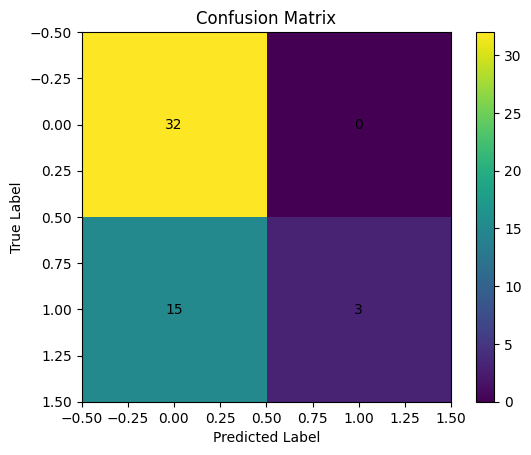

In [9]:
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

# Test dataset
test_dataset = IMDbDataset(test_encodings, test_labels)
test_loader = DataLoader(test_dataset, batch_size=8)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- EVALUATION ----------------
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

# ---------------- METRICS ----------------
accuracy = accuracy_score(all_labels, all_preds)

precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="binary"
)

cm = confusion_matrix(all_labels, all_preds)

# ---------------- PRINT ----------------
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nConfusion Matrix:")
print(cm)

# ================================
#  CONFUSION MATRIX GRAPH
# ================================

plt.figure()

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add values inside boxes
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.colorbar()
plt.show()

##EXPERIMENT

In [10]:
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt

In [11]:
def train_and_evaluate(model, train_loader, test_loader):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = AdamW(model.parameters(), lr=2e-5)

    # -------- TRAIN --------
    model.train()
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

    # -------- EVALUATE --------
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="binary"
    )

    return acc, precision, recall, f1

##EXPERIMENT 1 → Freeze BERT

In [12]:
model_exp1 = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2
)

# Freeze all layers
for param in model_exp1.bert.parameters():
    param.requires_grad = False

print("Running Experiment 1 (Frozen BERT)...")

acc1, p1, r1, f1_1 = train_and_evaluate(model_exp1, train_loader, test_loader)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Running Experiment 1 (Frozen BERT)...


##EXPERIMENT 2 → Fine-tune Last 2 Layers

In [13]:
model_exp2 = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2
)

# Freeze all layers first
for param in model_exp2.bert.parameters():
    param.requires_grad = False

# Unfreeze last 2 layers
for name, param in model_exp2.bert.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True

print("Running Experiment 2 (Last 2 layers trainable)...")

acc2, p2, r2, f2 = train_and_evaluate(model_exp2, train_loader, test_loader)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Running Experiment 2 (Last 2 layers trainable)...


##GRAPH COMPARISON

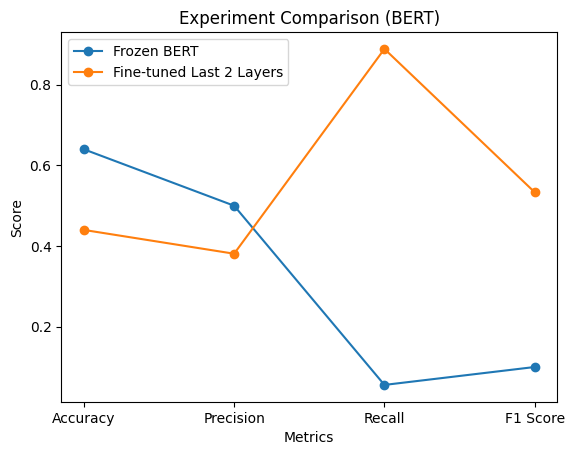

In [14]:
# ================================
# GRAPH COMPARISON
# ================================

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

exp1_scores = [acc1, p1, r1, f1_1]
exp2_scores = [acc2, p2, r2, f2]

x = range(len(metrics))

plt.figure()
plt.plot(x, exp1_scores, marker='o', label="Frozen BERT")
plt.plot(x, exp2_scores, marker='o', label="Fine-tuned Last 2 Layers")

plt.xticks(x, metrics)
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Experiment Comparison (BERT)")
plt.legend()

plt.show()

###
The graph shows that fine-tuning the last two layers of BERT performs better than freezing all layers. This improves model adaptability while maintaining pre-trained knowledge.